## **TASK 4 · Email Spam Detection with Machine Learning**

Objective: Build a Natural Language Processing (NLP) binary classifier that distinguishes spam emails from legitimate (ham) emails.

Tech Stack: Python, pandas, scikit-learn (TF-IDF, Naive Bayes/SVM), NLTK or re, Jupyter Notebook

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from wordcloud import WordCloud

## Download NLTK Data

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("spam.csv",encoding = "latin-1")
df.info()

Saving spam.csv to spam (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5572 non-null   int64 
 1   spamORham   5572 non-null   object
 2   Message     5572 non-null   object
dtypes: int64(1), object(2)
memory usage: 130.7+ KB


## Basic Inspection

In [ ]:
df.head()

,Unnamed: 0,spamORham,Message
0,0,ham,"Go until jurong point, crazy.. Available only ..."
1,1,ham,Ok lar... Joking wif u oni...
2,2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,3,ham,U dun say so early hor... U c already then say...
4,4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.tail()

,Unnamed: 0,spamORham,Message
5567,5567,spam,This is the 2nd time we have tried 2 contact u...
5568,5568,ham,Will Ã_ b going to esplanade fr home?
5569,5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,5570,ham,The guy did some bitching but I acted like i'd...
5571,5571,ham,Rofl. Its true to its name


In [ ]:
df.shape

(5572, 3)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
spamORham,0
Message,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Class Distribution

In [ ]:
#Count

df['spamORham'].value_counts()

,count
spamORham,
ham,4825
spam,747


In [ ]:
#Percentage%

(df['spamORham'].value_counts(normalize=True)*100)

,proportion
spamORham,
ham,86.593683
spam,13.406317


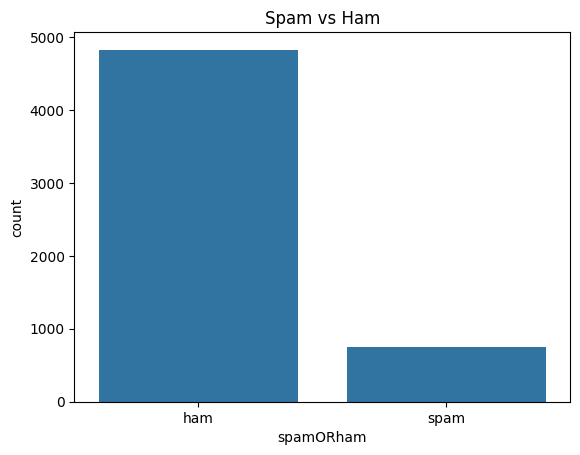

In [ ]:
#Plot

sns.countplot(data=df,x='spamORham')
plt.title("Spam vs Ham")
plt.show()

## Text Preprocessing

In [ ]:
ps = PorterStemmer()
def preprocess(text):
  text = text.lower()
  text = re.sub(r'[^a-zA-Z]','',text)
  words = text.split()
  words = [ps.stem(word) for word in words
           if word not in stopwords.words('english')]
  return"".join(words)

df['processed'] = df['Message'].apply(preprocess)

#TF-IDF
tfidf = TfidfVectorizer()
x= tfidf.fit_transform(df['processed'])
y = df['spamORham']

Text preprocessing converts all messages to lowercase, removes punctuation and numbers, eliminates common stopwords (such as "the", "is", "and"), and applies stemming to reduce words to their root form. This helps reduce noise and improves model performance.

TF-IDF (Term Frequency–Inverse Document Frequency) measures the importance of a word in a document relative to the entire dataset. Frequently occurring words in a document receive higher scores, while common words appearing in many documents receive lower scores.

## Train-Test Split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Model

In [ ]:
#Multinomial Naive Bayes ---1

nb = MultinomialNB()
nb.fit(x_train,y_train)
pred_nb = nb.predict(x_test)

print(accuracy_score(y_test,pred_nb))
print(confusion_matrix(y_test,pred_nb))
print(classification_report(y_test,pred_nb))

0.8699551569506726
[[965   0]
 [145   5]]
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       965
        spam       1.00      0.03      0.06       150

    accuracy                           0.87      1115
   macro avg       0.93      0.52      0.50      1115
weighted avg       0.89      0.87      0.81      1115



In [ ]:
#Logistic Regression ---2

lr = LogisticRegression()
lr.fit(x_train,y_train)
pred_lr = lr.predict(x_test)

print(accuracy_score(y_test,pred_lr))
print(confusion_matrix(y_test,pred_lr))
print(classification_report(y_test,pred_lr))

0.8699551569506726
[[965   0]
 [145   5]]
              precision    recall  f1-score   support

         ham       0.87      1.00      0.93       965
        spam       1.00      0.03      0.06       150

    accuracy                           0.87      1115
   macro avg       0.93      0.52      0.50      1115
weighted avg       0.89      0.87      0.81      1115



## Compare Model

In [ ]:
result =pd.DataFrame({

  "Model":["Naive Bayes","Logistic Regression"],

  "Accuracy":[
      accuracy_score(y_test,pred_nb),
      accuracy_score(y_test,pred_lr)
  ]
})

result

,Model,Accuracy
0,Naive Bayes,0.869955
1,Logistic Regression,0.869955


## Confusion Matrix Heatmap

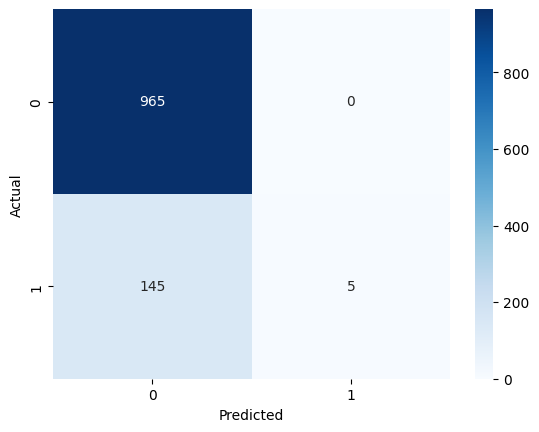

In [ ]:
cm = confusion_matrix(y_test,pred_nb)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Final Conclusion

This project developed an NLP-based spam detection system using TF-IDF feature extraction and two machine learning models: Multinomial Naive Bayes and Logistic Regression. After preprocessing the text and training the models, their performance was evaluated using accuracy, precision, recall, F1-score, and confusion matrix. The results demonstrated that machine learning can effectively distinguish spam from legitimate messages, making it suitable for real-world email filtering applications.